In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from opacus import PrivacyEngine

# Experiment parameters

In [2]:
# Set random seed for reproducibility
torch.manual_seed(0)

# Parameters
d = 10  # Dimensionality
n = 1000  # Number of data points
epochs = 10
learning_rate = 0.001
batch_size = 32

# Data generation

In [3]:
# Generate synthetic data
mean = torch.zeros(d)  # Zero mean
cov = torch.eye(d)  # Standard Gaussian
data = torch.distributions.MultivariateNormal(mean, cov).sample((n,))
target = mean.repeat(n, 1)  # Our target is the true mean repeated

# Create DataLoader
dataset = TensorDataset(data, target)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model

In [4]:
# Define a simple linear model
class LinearModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, input_dim, bias=False)

        # Initialize weights to 1
        torch.nn.init.constant_(self.fc.weight, 1.0)

    def forward(self, x):
        return self.fc(x)

In [5]:
def train_dp_model(data_loader, epochs, learning_rate, max_grad_norm, epsilon):
    print(f'Running with maximum gradient norm: {max_grad_norm}')

    model = LinearModel(d)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Initialize Privacy Engine
    privacy_engine = PrivacyEngine()
    model, optimizer, data_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=data_loader,
        target_epsilon=epsilon,
        target_delta=1e-5,
        max_grad_norm=max_grad_norm,
        epochs=epochs,
    )

    criterion = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        print(f' - Iterate epoch: {epoch}')
        epoch_loss = 0
        for batch_data, batch_target in data_loader:
            optimizer.zero_grad()
            output = model(batch_data)
            loss = criterion(output, batch_target)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(data_loader)
        losses.append(avg_loss)

    return losses[-1]  # Return the final loss

In [8]:
def plot_results(max_grad_norms, results, epsilon):
    plt.figure(figsize=(10, 6))
    plt.plot(max_grad_norms, results, label=f"Epsilon = {epsilon}", marker='o')
    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('MSE Loss')
    plt.title('Effect of Maximum Gradient Norm on Toy model')
    plt.legend()
    plt.xlim([0, 15])
    plt.grid(True)
    plt.show()

Running for epsilon: 0.25
Running with maximum gradient norm: 0.0001
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.00024616309676992636
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0006059627021136012
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0014916565527935632
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch

/tmp/ipykernel_538456/1829528065.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 15])


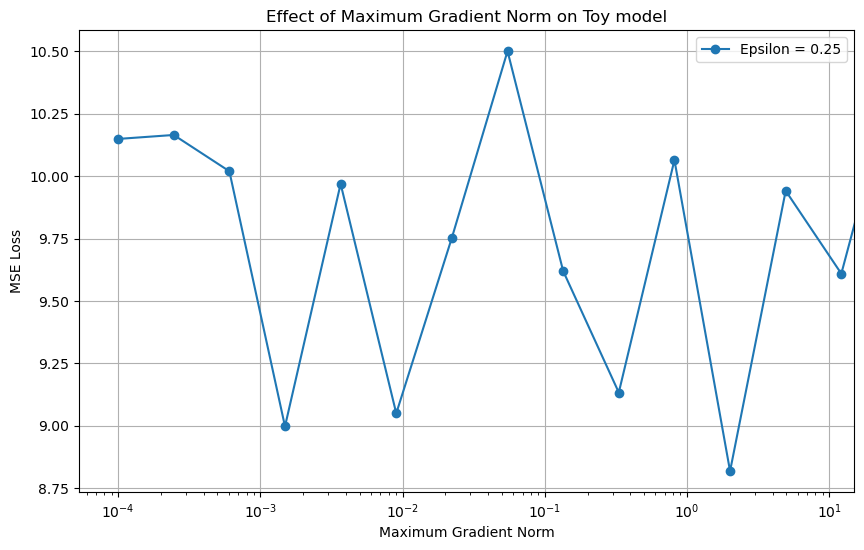

Running for epsilon: 1
Running with maximum gradient norm: 0.0001
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.00024616309676992636
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0006059627021136012
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0014916565527935632
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7

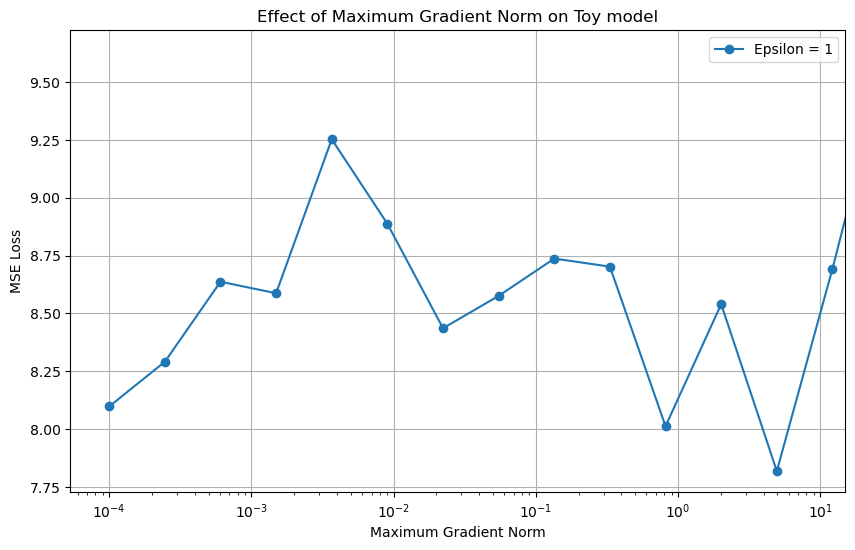

Running for epsilon: 4
Running with maximum gradient norm: 0.0001
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.00024616309676992636
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0006059627021136012
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0014916565527935632
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7

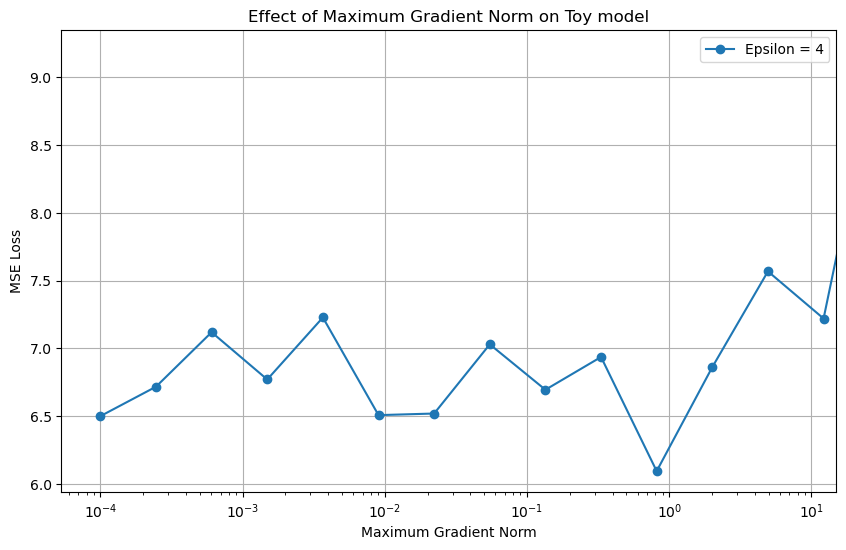

In [11]:
max_grad_norms = np.geomspace(1e-4, 30, 15)
epsilon_values = [0.25, 1, 4]

for epsilon in epsilon_values:
    print(f'Running for epsilon: {epsilon}')
    results = [train_dp_model(data_loader, epochs, learning_rate, max_grad_norm, epsilon) for max_grad_norm in max_grad_norms]
    plot_results(max_grad_norms, results, epsilon)
